In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

# Load/Prepare Data

In [2]:
# Load Values
values = pd.read_csv("../Evaluation/metrics_evaluation.csv", index_col=0, header=[0, 1])

# Load Germany's shape
germany = gpd.read_file('../Data/Wind/germany_shape/de.shp')

# Load coordinates and location IDs
coordinates = pd.read_csv('../Data/Wind/coordinates.csv', index_col=0, header=0)
latitudes = coordinates['Latitude']
longitudes = coordinates['Longitude']

ERROR 1: PROJ: proj_create_from_database: Open of /home/phillip-schlicht/python/miniforge3/envs/meteo/share/proj failed


# Best model per location

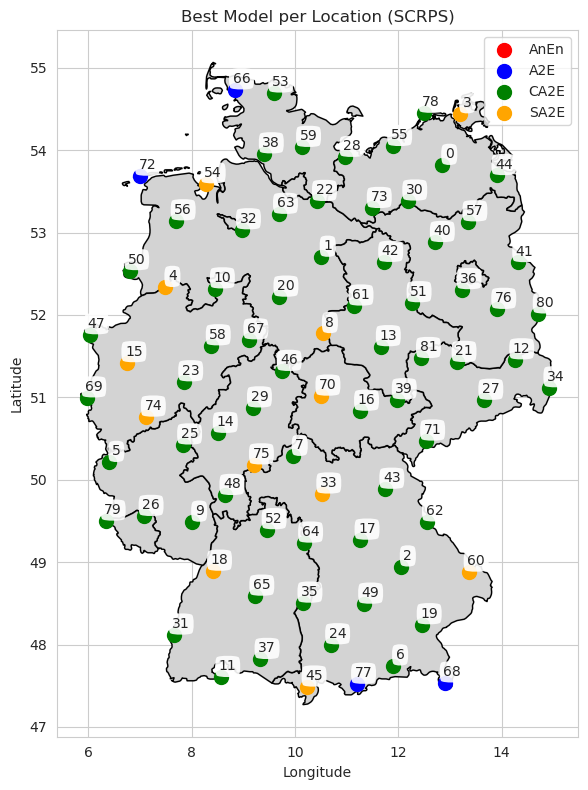

In [3]:
# Find the best Model per location
def get_best_locations(df):
    best_locations = {}
    for model in df.columns:
        best_locations[model] = df.index[df[model] == df.min(axis=1)].tolist()
    return best_locations

metric = "SCRPS"
best_locations = get_best_locations(values.loc[:, metric])

# Plot Germany's outline and coordinates
fig, ax = plt.subplots(figsize=(8, 8))
germany.boundary.plot(ax=ax, color='black', alpha=0.1, zorder=2)
germany.plot(ax=ax, color='lightgray', edgecolor='black', zorder=1)

# Define colors for each model
colors = ['red', 'blue', 'green', 'orange']

# Plot best locations for each model
for i, (model, locations) in enumerate(best_locations.items()):
    # Get the indices of the best locations for the current model
    indices = [coordinates.index[coordinates.index == loc].tolist()[0] for loc in locations if loc in coordinates.index.values]
    # Plot the best locations for the current model with a specific color
    ax.scatter(longitudes[indices], latitudes[indices], color=colors[i % len(colors)], label=model, s=100, zorder=3)

# Define bbox properties
bbox_props = dict(boxstyle="round4", facecolor="white", alpha=0.9, edgecolor='none')

# Annotate each point with its location ID and a bbox
for loc_id, (lon, lat) in enumerate(zip(longitudes, latitudes)):
    ax.annotate(loc_id,
                (lon, lat),
                textcoords="offset points",
                xytext=(5,5),
                ha='center',
                bbox=bbox_props,
                zorder=3)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Best Model per Location ({metric})')
ax.legend()
plt.tight_layout()
plt.savefig('../Evaluation/figures/best_model_per_location.png')
plt.show()
plt.close()

# Boxplots

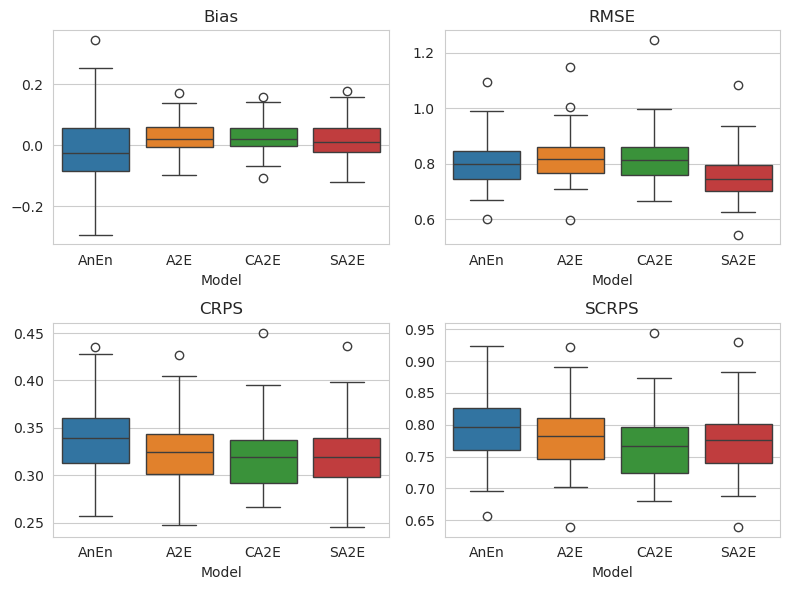

In [4]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8, 6))
sns.boxplot(values.Bias, ax=ax[0,0]).set_title("Bias")
sns.boxplot(values.RMSE, ax=ax[0,1]).set_title("RMSE")
sns.boxplot(values.CRPS, ax=ax[1,0]).set_title("CRPS")
sns.boxplot(values.SCRPS, ax=ax[1,1]).set_title("SCRPS")
plt.tight_layout()
plt.savefig("../Evaluation/figures/metrics_boxplot.png")
plt.show()
plt.close()